In [53]:
import numpy as np
import pandas as pd
import numpy as mp
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sc
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [54]:
df = pd.read_csv('glass.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [55]:
df.columns = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

print(df.columns)

Index(['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='str')


In [56]:
df.info()

print('Nulls - ', df.isnull().sum())
print('Description -', df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      214 non-null    int64  
 1   RI      214 non-null    float64
 2   Na      214 non-null    float64
 3   Mg      214 non-null    float64
 4   Al      214 non-null    float64
 5   Si      214 non-null    float64
 6   K       214 non-null    float64
 7   Ca      214 non-null    float64
 8   Ba      214 non-null    float64
 9   Fe      214 non-null    float64
 10  Type    214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB
Nulls -  Id      0
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64
Description -                Id          RI          Na          Mg          Al          Si  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean   107.500000    1.518365   13.407850    2.684533    1.444907 

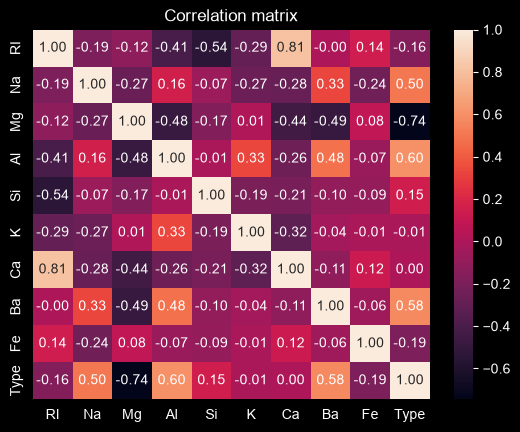

In [57]:
df = df.drop(columns=['Id'])

sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('Correlation matrix')
plt.show()

In [58]:
X = df.drop(columns=['Type'])
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for idx, num in enumerate(np.bincount(y_train)):
    print(f'Number {idx} has appeared {num} times')

Number 0 has appeared 0 times
Number 1 has appeared 59 times
Number 2 has appeared 62 times
Number 3 has appeared 14 times
Number 4 has appeared 0 times
Number 5 has appeared 9 times
Number 6 has appeared 6 times
Number 7 has appeared 21 times


In [59]:
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampl, y_train_resampl = smote.fit_resample(X_train_scaled, y_train)

for idx, num in enumerate(np.bincount(y_train_resampl)):
    print(f'Number {idx} has appeared {num} times')

Number 0 has appeared 0 times
Number 1 has appeared 62 times
Number 2 has appeared 62 times
Number 3 has appeared 62 times
Number 4 has appeared 0 times
Number 5 has appeared 62 times
Number 6 has appeared 62 times
Number 7 has appeared 62 times


In [60]:
boosting = HistGradientBoostingClassifier(random_state=42)
boosting.fit(X_train_resampl, y_train_resampl)

pred = boosting.predict(X_test_scaled)
print('Accuracy - ', accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))

Accuracy -  0.813953488372093
              precision    recall  f1-score   support

           1       0.80      0.73      0.76        11
           2       0.83      0.71      0.77        14
           3       0.60      1.00      0.75         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.80      1.00      0.89         8

    accuracy                           0.81        43
   macro avg       0.84      0.87      0.84        43
weighted avg       0.83      0.81      0.81        43

